In [ ]:
import os, sys, zipfile

REPO_URL  = 'https://github.com/JeremyMaille/urban-change-detection.git'
REPO_NAME = 'urban-change-detection'
REPO_PATH = f'/content/{REPO_NAME}'
SRC_PATH  = f'{REPO_PATH}/src'
DATA_PATH = f'{REPO_PATH}/data/levir'

# Monte Google Drive
from google.colab import drive
drive.mount('/gdrive')

# Clone ou met à jour le repo
os.chdir('/content')
if not os.path.isdir(REPO_NAME):
    !git clone {REPO_URL}
else:
    !git -C {REPO_NAME} pull

os.chdir(REPO_PATH)
!pip install -q -r requirements.txt

# Télécharge le dataset depuis HuggingFace si absent
os.makedirs(DATA_PATH, exist_ok=True)
zip_path = f'{DATA_PATH}/LEVIR-CD+.zip'

if not os.path.exists(zip_path):
    print("Téléchargement LEVIR-CD+...")
    !wget -q --show-progress \
        "https://huggingface.co/datasets/satellite-image-deep-learning/LEVIR-CD/resolve/d4f83dcbb571ee7573079129a5c327d18592a849/LEVIR-CD+.zip" \
        -O "{zip_path}"

from torchgeo.datasets import LEVIRCDPlus
LEVIRCDPlus(root=DATA_PATH, split='train', download=True)
LEVIRCDPlus(root=DATA_PATH, split='test',  download=True)

os.makedirs(f'{REPO_PATH}/checkpoints', exist_ok=True)
os.makedirs(f'{REPO_PATH}/notebooks',   exist_ok=True)
sys.path.insert(0, SRC_PATH)

print(f'Répertoire : {os.getcwd()}')
print(f'Dataset OK : {os.listdir(DATA_PATH)}')

Mounted at /gdrive
Cloning into 'urban-change-detection'...
remote: Enumerating objects: 56, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 56 (delta 15), reused 53 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (56/56), 25.60 MiB | 23.55 MiB/s, done.
Resolving deltas: 100% (15/15), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 117.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 123.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 85.2 MB/s eta 0:0

In [ ]:
import os, sys
sys.path.insert(0, '/content/urban-change-detection/src')

import torch
import numpy as np
import matplotlib.pyplot as plt

from datasets.dataset import make_dataloaders
from models.siamese_unet import SiameseUNet
from training.trainer import CombinedLoss, train_one_epoch, evaluate

print('Imports OK')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

Imports OK
PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : Tesla T4


In [ ]:
DATA_ROOT = '/content/urban-change-detection/data/levir'

CONFIG = {
    'patch_size'  : 256,
    'batch_size'  : 8,
    'lr'          : 1e-4,
    'weight_decay': 1e-4,
    'epochs'      : 50,
    'pos_weight'  : 10.0,
    'base_filters': 32,
    'patience'    : 10,
    'checkpoint'  : '/content/urban-change-detection/checkpoints/best_model.pt',
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'Config : {CONFIG}')

Device : cuda
Config : {'patch_size': 256, 'batch_size': 8, 'lr': 0.0001, 'weight_decay': 0.0001, 'epochs': 50, 'pos_weight': 10.0, 'base_filters': 32, 'patience': 10, 'checkpoint': '/content/urban-change-detection/checkpoints/best_model.pt'}


In [ ]:
train_loader, val_loader, test_loader = make_dataloaders(
    root       = DATA_ROOT,
    patch_size = CONFIG['patch_size'],
    batch_size = CONFIG['batch_size'],
)

print(f'Train : {len(train_loader.dataset)} patches')
print(f'Val   : {len(val_loader.dataset)} patches')
print(f'Test  : {len(test_loader.dataset)} patches')

batch = next(iter(train_loader))
print(f'\nShape t1   : {batch["t1"].shape}')
print(f'Shape t2   : {batch["t2"].shape}')
print(f'Shape mask : {batch["mask"].shape}')

Train : 9184 patches
Val   : 1008 patches
Test  : 5568 patches

Shape t1   : torch.Size([8, 3, 256, 256])
Shape t2   : torch.Size([8, 3, 256, 256])
Shape mask : torch.Size([8, 1, 256, 256])


In [ ]:
model = SiameseUNet(in_channels=3, pretrained=True).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Paramètres : {n_params / 1e6:.2f}M')

criterion = CombinedLoss(pos_weight=CONFIG['pos_weight'])

# Encodeur à lr/10 — préserve les features ImageNet pendant que le décodeur apprend
encoder_params = list(model.enc0.parameters()) + \
                 list(model.enc1.parameters()) + \
                 list(model.enc2.parameters()) + \
                 list(model.enc3.parameters()) + \
                 list(model.enc4.parameters())

decoder_params = list(model.dec4.parameters()) + \
                 list(model.dec3.parameters()) + \
                 list(model.dec2.parameters()) + \
                 list(model.dec1.parameters()) + \
                 list(model.head.parameters())

optimizer = torch.optim.AdamW([
    {'params': encoder_params, 'lr': CONFIG['lr'] / 10},
    {'params': decoder_params, 'lr': CONFIG['lr']},
], weight_decay=CONFIG['weight_decay'])

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

Paramètres : 23.82M


In [ ]:
history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_iou': []}
best_f1      = 0.0
patience_cpt = 0

for epoch in range(1, CONFIG['epochs'] + 1):
    train_loss, train_m = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_m   = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_m['f1'])

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_m['f1'])
    history['val_iou'].append(val_m['iou'])

    print(
        f"Epoch {epoch:02d}/{CONFIG['epochs']} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val F1: {val_m['f1']:.4f} | "
        f"Val IoU: {val_m['iou']:.4f}"
    )

    if val_m['f1'] > best_f1:
        best_f1      = val_m['f1']
        patience_cpt = 0
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'val_f1'     : best_f1,
            'config'     : CONFIG,
        }, CONFIG['checkpoint'])
        print(f'  → Checkpoint sauvegardé (F1={best_f1:.4f})')
    else:
        patience_cpt += 1
        if patience_cpt >= CONFIG['patience']:
            print(f'Early stopping à l epoch {epoch}.')
            break

Epoch 01/50 | Train loss: 1.1685 | Val loss: 0.9328 | Val F1: 0.4818 | Val IoU: 0.3537
  → Checkpoint sauvegardé (F1=0.4818)
Epoch 02/50 | Train loss: 0.7576 | Val loss: 0.7063 | Val F1: 0.6098 | Val IoU: 0.4983
  → Checkpoint sauvegardé (F1=0.6098)
Epoch 03/50 | Train loss: 0.5605 | Val loss: 0.6147 | Val F1: 0.6153 | Val IoU: 0.5023
  → Checkpoint sauvegardé (F1=0.6153)
Epoch 04/50 | Train loss: 0.4631 | Val loss: 0.6231 | Val F1: 0.6408 | Val IoU: 0.5460
  → Checkpoint sauvegardé (F1=0.6408)
Epoch 05/50 | Train loss: 0.4267 | Val loss: 0.5403 | Val F1: 0.6320 | Val IoU: 0.5301
Epoch 06/50 | Train loss: 0.3911 | Val loss: 0.5368 | Val F1: 0.6574 | Val IoU: 0.5663
  → Checkpoint sauvegardé (F1=0.6574)
Epoch 07/50 | Train loss: 0.3701 | Val loss: 0.5474 | Val F1: 0.6628 | Val IoU: 0.5748
  → Checkpoint sauvegardé (F1=0.6628)
Epoch 08/50 | Train loss: 0.3593 | Val loss: 0.5106 | Val F1: 0.6513 | Val IoU: 0.5543
Epoch 09/50 | Train loss: 0.3563 | Val loss: 0.5404 | Val F1: 0.6730 | Val I

In [ ]:
checkpoint = torch.load(CONFIG['checkpoint'], map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f"Meilleur modèle : epoch {checkpoint['epoch']}, Val F1={checkpoint['val_f1']:.4f}")

_, test_m = evaluate(model, test_loader, criterion, device)

BASELINE_F1 = 0.0951
print()
print('=' * 45)
print('Résultats finaux — Test set')
print('=' * 45)
print(f"  F1        : {test_m['f1']:.4f}")
print(f"  IoU       : {test_m['iou']:.4f}")
print(f"  Précision : {test_m['precision']:.4f}")
print(f"  Rappel    : {test_m['recall']:.4f}")
print()
print(f"  Baseline CVA F1  : {BASELINE_F1:.4f}")
print(f"  Siamese U-Net F1 : {test_m['f1']:.4f}")
print(f"  Gain             : +{(test_m['f1'] - BASELINE_F1):.4f}")

Meilleur modèle : epoch 31, Val F1=0.7019

Résultats finaux — Test set
  F1        : 0.5359
  IoU       : 0.4496
  Précision : 0.5322
  Rappel    : 0.6069

  Baseline CVA F1  : 0.0951
  Siamese U-Net F1 : 0.5359
  Gain             : +0.4408


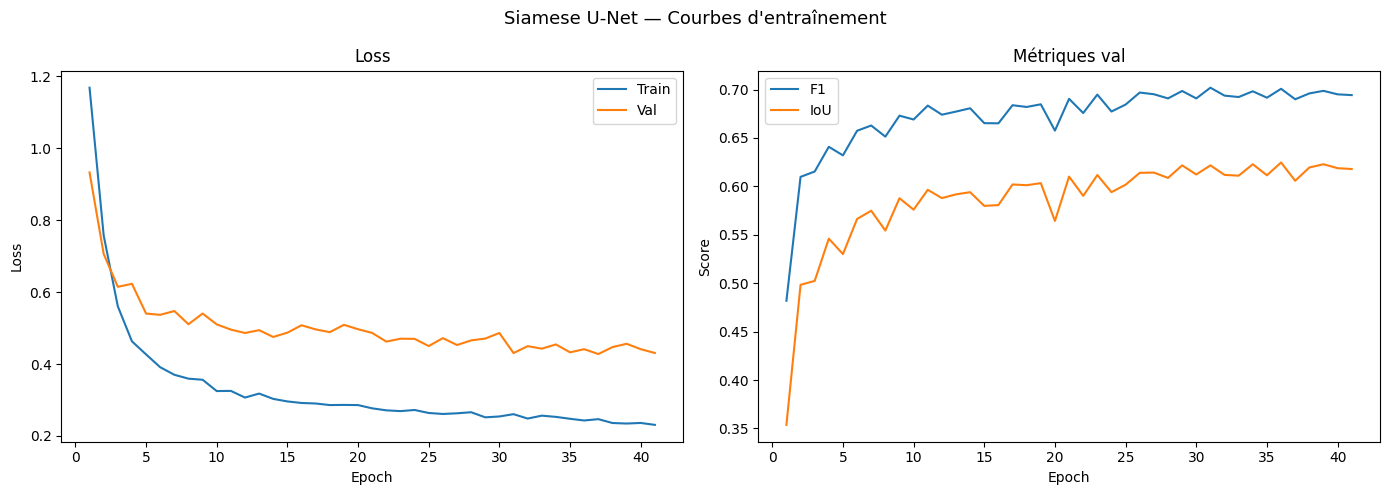

In [ ]:
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Siamese U-Net — Courbes d'entraînement", fontsize=13)

axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'],   label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(epochs_range, history['val_f1'],  label='F1')
axes[1].plot(epochs_range, history['val_iou'], label='IoU')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
axes[1].set_title('Métriques val'); axes[1].legend()

plt.tight_layout()
plt.savefig('notebooks/training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
checkpoint = torch.load(CONFIG['checkpoint'], map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f"Meilleur modèle : epoch {checkpoint['epoch']}, Val F1={checkpoint['val_f1']:.4f}")

_, test_m = evaluate(model, test_loader, criterion, device)

BASELINE_F1 = 0.0951
print()
print('=' * 45)
print('Résultats finaux — Test set')
print('=' * 45)
print(f"  F1        : {test_m['f1']:.4f}")
print(f"  IoU       : {test_m['iou']:.4f}")
print(f"  Précision : {test_m['precision']:.4f}")
print(f"  Rappel    : {test_m['recall']:.4f}")
print()
print(f"  Baseline CVA F1  : {BASELINE_F1:.4f}")
print(f"  Siamese U-Net F1 : {test_m['f1']:.4f}")
print(f"  Gain             : +{(test_m['f1'] - BASELINE_F1):.4f}")

Meilleur modèle : epoch 31, Val F1=0.7019

Résultats finaux — Test set
  F1        : 0.5359
  IoU       : 0.4496
  Précision : 0.5322
  Rappel    : 0.6069

  Baseline CVA F1  : 0.0951
  Siamese U-Net F1 : 0.5359
  Gain             : +0.4408


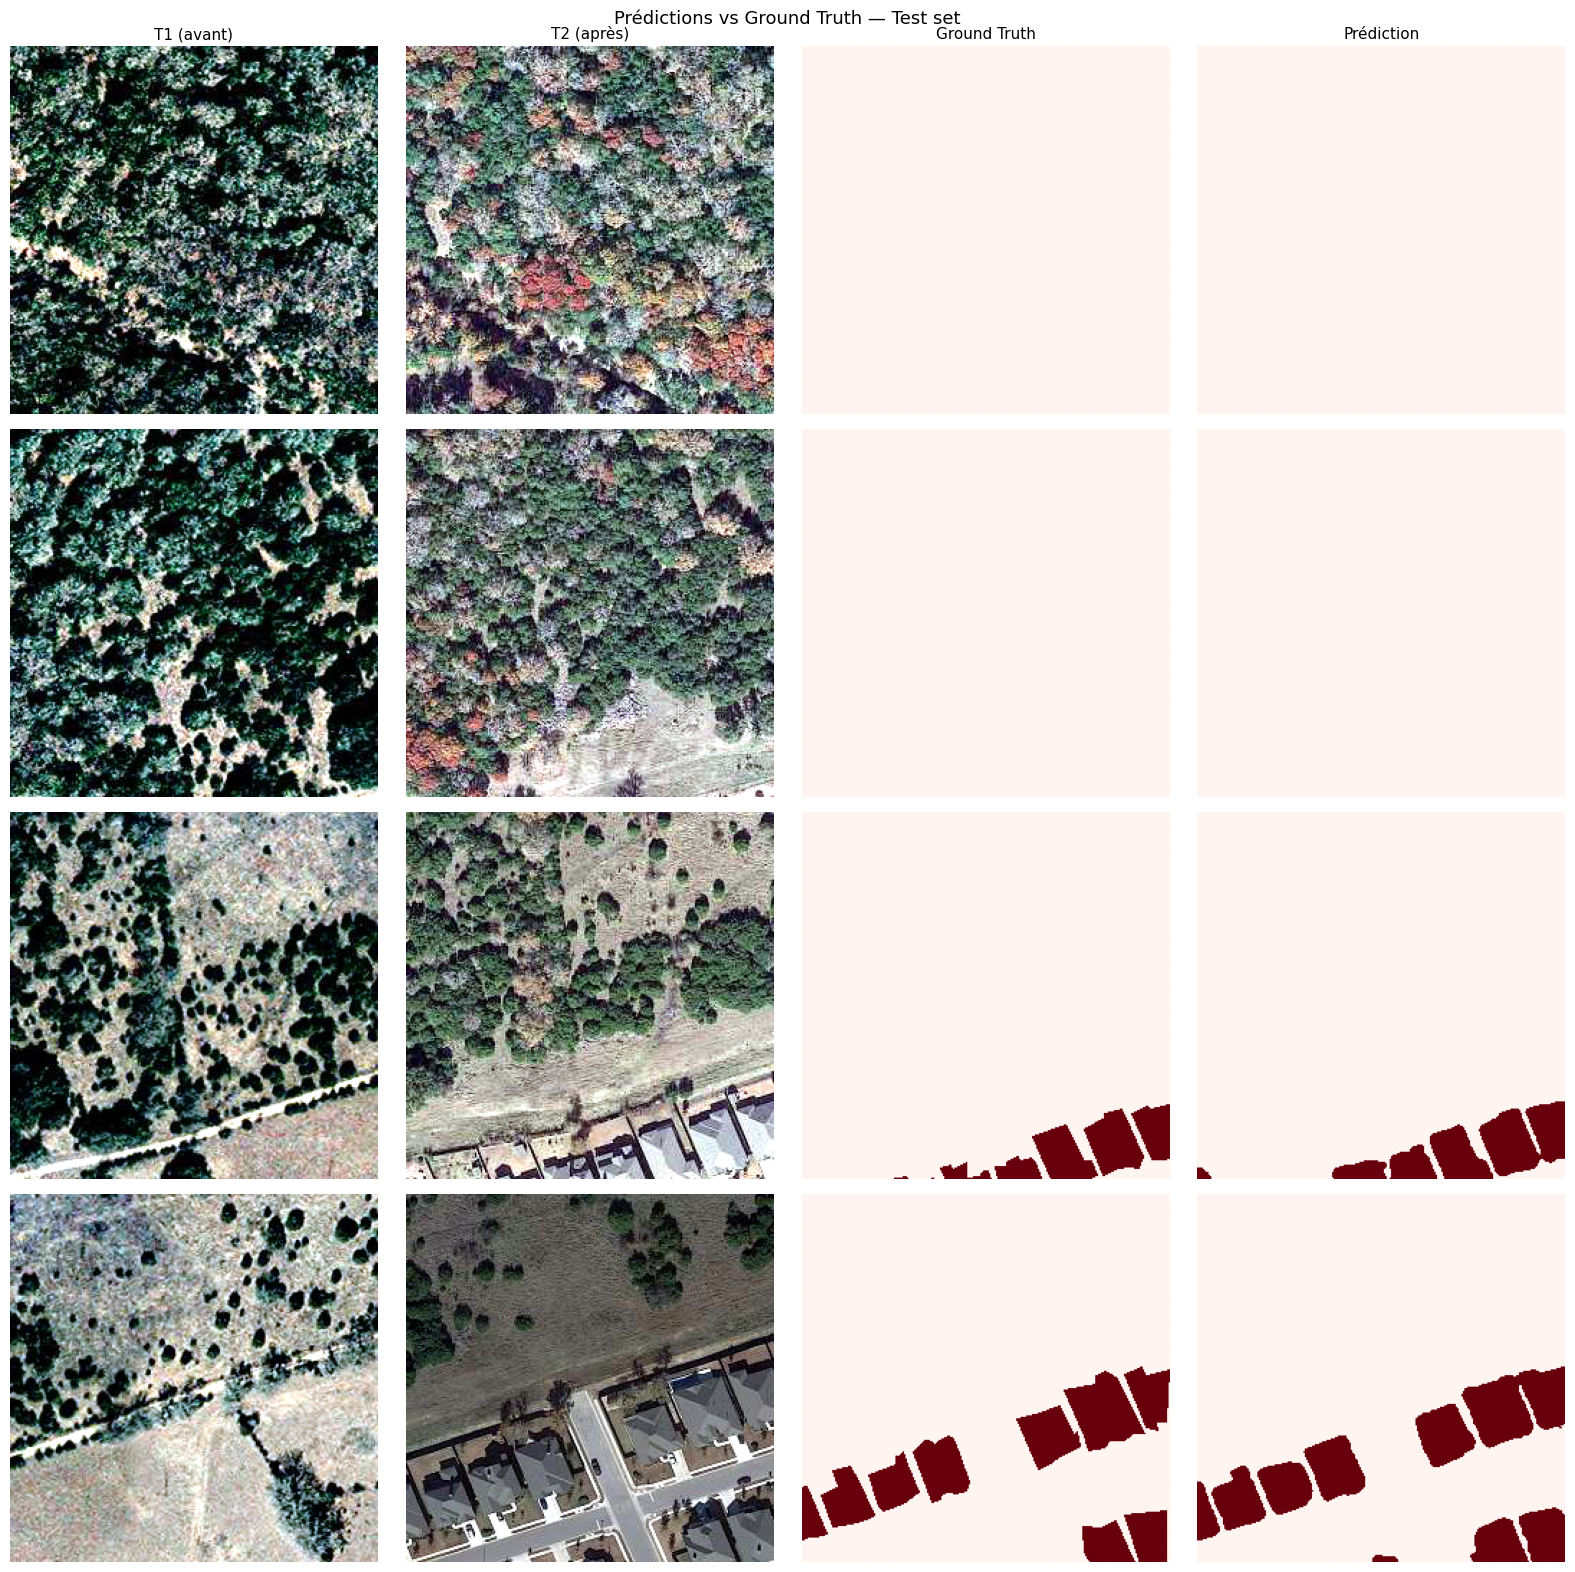

In [ ]:
def to_rgb(tensor):
    img = tensor.numpy().transpose(1, 2, 0).astype(np.float32)
    for c in range(3):
        p2, p98 = np.percentile(img[:, :, c], 2), np.percentile(img[:, :, c], 98)
        img[:, :, c] = np.clip((img[:, :, c] - p2) / (p98 - p2 + 1e-6), 0, 1)
    return img

model.eval()
batch = next(iter(test_loader))
with torch.no_grad():
    logits = model(batch['t1'].to(device), batch['t2'].to(device))
    preds  = (torch.sigmoid(logits) > 0.5).float().cpu()

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('Prédictions vs Ground Truth — Test set', fontsize=13)

for ax, col in zip(axes[0], ['T1 (avant)', 'T2 (après)', 'Ground Truth', 'Prédiction']):
    ax.set_title(col, fontsize=11)

for row in range(4):
    axes[row, 0].imshow(to_rgb(batch['t1'][row]));  axes[row, 0].axis('off')
    axes[row, 1].imshow(to_rgb(batch['t2'][row]));  axes[row, 1].axis('off')
    axes[row, 2].imshow(batch['mask'][row, 0].numpy(), cmap='Reds'); axes[row, 2].axis('off')
    axes[row, 3].imshow(preds[row, 0].numpy(),         cmap='Reds'); axes[row, 3].axis('off')

plt.tight_layout()
plt.savefig('notebooks/predictions.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
import shutil
shutil.copy(
    CONFIG['checkpoint'],
    '/gdrive/MyDrive/urban_cd_best_model.pt'
)
print('Checkpoint sauvegardé sur Google Drive.')

Checkpoint sauvegardé sur Google Drive.
